In [3]:
# ============================================================
# CELL 1 — Install Dependencies
# ============================================================
!apt-get update -y && apt-get install -y cmake libopenmpi-dev python3-dev zlib1g-dev swig
!pip install stable-baselines3[extra]
!pip install git+https://github.com/AI4Finance-Foundation/FinRL.git
!pip install websockets>=15.0.0 --quiet


# ============================================================
# CELL 2 — All Imports
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import pkg_resources

import torch as th
import torch.nn as nn

import stable_baselines3
import finrl

import sys
sys.path.append('.')
from utils import (
    prepare_df, compute_metrics, compute_rolling_metrics,
    plot_metrics, compute_buy_and_hold, overfitting_check,
    check_degenerate_policy, check_lookahead_bias,
    regime_analysis, run_full_evaluation
)

from stable_baselines3.common.torch_layers import BaseFeaturesExtractor
from finrl.meta.preprocessor.yahoodownloader import YahooDownloader
from finrl.meta.preprocessor.preprocessors import FeatureEngineer
from finrl.agents.stablebaselines3.models import DRLAgent
from finrl.meta.env_stock_trading.env_stocktrading import StockTradingEnv
from finrl.config import INDICATORS

%matplotlib inline
plt.close('all')

print(f"SB3 Version:    {stable_baselines3.__version__}")
print(f"FinRL Version:  {pkg_resources.get_distribution('finrl').version}")
print(f"CUDA Available: {th.cuda.is_available()}")

# ── Mac GPU (Metal / MPS) detection ──────────────────────────────────────────
if th.backends.mps.is_available():
    DEVICE = th.device('mps')
    print("MPS (Apple Metal GPU) available — using GPU ✓")
elif th.cuda.is_available():
    DEVICE = th.device('cuda')
    print(f"CUDA GPU available — using {th.cuda.get_device_name(0)} ✓")
else:
    DEVICE = th.device('cpu')
    print("No GPU found — falling back to CPU")

print(f"Active device: {DEVICE}")


# ============================================================
# CELL 3 — Download Data
# ============================================================
TICKERS = [
    'NVDA', 'AAPL', 'GOOGL', 'GOOG', 'MSFT', 'AMZN', 'META', 'AVGO', 'TSLA',
    'WMT', 'LLY', 'JPM', 'XOM', 'V', 'JNJ', 'MU','MA', 'COST', 'ORCL',
    'ABBV',  'BAC', 'HD', 'PG', 'CVX', 'GE', 'CAT',  'KO', 'NFLX', 'AMD','CSCO'
]
NUM_STOCKS = len(TICKERS)  # 30 — use this constant everywhere, no magic numbers

# Download training data
df_raw_train = YahooDownloader(
    start_date='2020-01-01',
    end_date='2024-01-01',
    ticker_list=TICKERS
).fetch_data()

# Download test data (held-out period)
df_raw_test = YahooDownloader(
    start_date='2024-01-01',
    end_date='2025-01-01',
    ticker_list=TICKERS
).fetch_data()

# Add Technical Indicators
fe = FeatureEngineer(
    use_technical_indicator=True,
    tech_indicator_list=INDICATORS,
    use_vix=False,
    use_turbulence=False
)

df_train_raw = fe.preprocess_data(df_raw_train)
df_test_raw  = fe.preprocess_data(df_raw_test)
print(f"Train raw shape: {df_train_raw.shape}")
print(f"Test raw shape:  {df_test_raw.shape}")


# ============================================================
# CELL 4 — Clean & Validate Data
# ============================================================

# ── For BASELINE notebooks (no sentiment) ────────────────────
from finrl.config import INDICATORS
INDICATORS_LIST  = INDICATORS
INDICATORS_COUNT = len(INDICATORS_LIST)   # 8

df_train = prepare_df(df_train_raw)
df_test  = prepare_df(df_test_raw)

TICKERS    = sorted(df_train['tic'].unique().tolist())
NUM_STOCKS = len(TICKERS)

INDICATORS_START_IDX = 1 + NUM_STOCKS + NUM_STOCKS
STATE_SPACE          = INDICATORS_START_IDX + (NUM_STOCKS * INDICATORS_COUNT)
print(f"NUM_STOCKS: {NUM_STOCKS}, STATE_SPACE: {STATE_SPACE}")

# ============================================================
# CELL 5 — Define Model & Train
# ============================================================
INDICATORS_COUNT     = len(INDICATORS)                        # typically 8
INDICATORS_START_IDX = 1 + NUM_STOCKS + NUM_STOCKS           # skip: Cash + Prices + Shares
STATE_SPACE          = INDICATORS_START_IDX + (NUM_STOCKS * INDICATORS_COUNT)

class VGG_FinRL_Extractor(BaseFeaturesExtractor):
    def __init__(self, observation_space, features_dim=512, n_stocks=NUM_STOCKS, n_ind=INDICATORS_COUNT):
        super().__init__(observation_space, features_dim)
        self.n_stocks = n_stocks
        self.n_ind    = n_ind

        self.input_norm = nn.BatchNorm2d(1)

        self.vgg = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),
        )

        # Probe passes through input_norm to stay consistent with forward()
        with th.no_grad():
            # Use CPU for the probe — MPS doesn't support BatchNorm in inference mode
            sample    = th.zeros(1, 1, n_stocks, n_ind)
            _norm_cpu = nn.BatchNorm2d(1)
            _vgg_cpu  = nn.Sequential(
                nn.Conv2d(1, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
                nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            )
            sample    = _norm_cpu(sample)
            n_flatten = _vgg_cpu(sample).numel()

        # Dropout removed — it destabilises the RL critic's value estimates
        self.fc = nn.Sequential(
            nn.Linear(n_flatten, features_dim),
            nn.ReLU()
        )

    def forward(self, observations):
        img_data = observations[:, INDICATORS_START_IDX:]
        img_data = img_data.view(-1, 1, self.n_stocks, self.n_ind)
        img_data = self.input_norm(img_data)
        x = self.vgg(img_data)
        x = th.flatten(x, start_dim=1)
        return self.fc(x)

policy_kwargs = dict(
    features_extractor_class=VGG_FinRL_Extractor,
    features_extractor_kwargs=dict(
        features_dim=512,
        n_stocks=NUM_STOCKS,
        n_ind=INDICATORS_COUNT
    ),
)

def make_env(df):
    return StockTradingEnv(
        df=df,
        num_stock_shares    = [0] * NUM_STOCKS,
        reward_scaling      = 1e-4,
        stock_dim           = NUM_STOCKS,
        hmax                = 10,          # 100/$1M, 10/$100k, 5/$10k
        initial_amount      = 100_000,    # change per capital level
        buy_cost_pct        = [0.0015] * NUM_STOCKS,  # 0.1% + 0.05% slippage
        sell_cost_pct       = [0.0015] * NUM_STOCKS,
        state_space         = STATE_SPACE,
        tech_indicator_list = INDICATORS_LIST,
        action_space        = NUM_STOCKS
    )

e_train_gym = make_env(df_train)
e_test_gym  = make_env(df_test)

env_train, _ = e_train_gym.get_sb_env()

model_params = {
    "n_steps":       2048,
    "ent_coef":      0.01,
    "learning_rate": 0.0001,
    "batch_size":    64,
    "device":        DEVICE,   # <-- uses MPS on Mac, CUDA if available, else CPU
}

agent     = DRLAgent(env=env_train)
model_vgg = agent.get_model(
    "ppo",
    policy_kwargs=policy_kwargs,
    model_kwargs=model_params,
    verbose=1
)

print("Starting VGG Training...")
# Increased timesteps — 100k is too few for 30 stocks; start at 500k
trained_vgg = agent.train_model(
    model=model_vgg,
    tb_log_name='vgg_ppo_run',
    total_timesteps=500_000
)


# ============================================================
# CELL 6 — Sanity Check Training Behaviour
# ============================================================
shares_start = 1 + NUM_STOCKS   # skip Cash + Prices
shares_end   = shares_start + NUM_STOCKS

final_shares = np.array(e_train_gym.state_memory)[-1][shares_start:shares_end]
print(f"Total shares held across all stocks: {np.sum(final_shares)}")

actions = np.array(e_train_gym.actions_memory)
print(f"Average absolute action strength: {np.mean(np.abs(actions)):.6f}")

def compute_metrics(df_account_value: pd.DataFrame,
                    initial_capital: float = 100_000) -> dict:
    """
    Compute key trading performance metrics from account value history.

    Metrics:
      - Total Return:       overall % gain/loss
      - Sharpe Ratio:       risk-adjusted return (annualised)
      - Max Drawdown:       largest peak-to-trough decline (%)
      - Win Rate:           % of days with positive return
      - Avg Daily Return:   mean daily % return
      - Volatility:         annualised std of daily returns
      - Calmar Ratio:       total return / max drawdown
    """
    values  = pd.Series(df_account_value['account_value'].values,
                        index=pd.to_datetime(df_account_value['date'].values))

    # Daily returns
    daily_returns = values.pct_change().dropna()

    # Total return
    total_return = (values.iloc[-1] - initial_capital) / initial_capital * 100

    # Sharpe ratio (annualised, assuming 252 trading days)
    sharpe = (daily_returns.mean() / daily_returns.std()) * np.sqrt(252) \
             if daily_returns.std() > 0 else 0.0

    # Maximum drawdown
    rolling_max  = values.cummax()
    drawdown     = (values - rolling_max) / rolling_max * 100
    max_drawdown = drawdown.min()   # most negative value = worst drawdown

    # Win rate — % of days with positive return
    win_rate = (daily_returns > 0).sum() / len(daily_returns) * 100

    # Average daily return
    avg_daily_return = daily_returns.mean() * 100

    # Annualised volatility
    volatility = daily_returns.std() * np.sqrt(252) * 100

    # Calmar ratio (total return / abs max drawdown)
    calmar = abs(total_return / max_drawdown) if max_drawdown != 0 else 0.0

    RF_DAILY = 0.05 / 252
    sharpe   = ((daily_returns.mean() - RF_DAILY) /
             daily_returns.std()) * np.sqrt(252)

    return {
        'Total Return (%)':     round(total_return, 2),
        'Sharpe Ratio':         round(sharpe, 3),
        'Max Drawdown (%)':     round(max_drawdown, 2),
        'Win Rate (%)':         round(win_rate, 2),
        'Avg Daily Return (%)': round(avg_daily_return, 4),
        'Volatility (%)':       round(volatility, 2),
        'Calmar Ratio':         round(calmar, 3),
    }


# Compute and print metrics for training environment
# We need to run a quick prediction pass on the training env
# to get a clean account value history
df_train_account, _ = DRLAgent.DRL_prediction(
    model=trained_vgg,
    environment=e_train_gym
)


zsh:1: command not found: apt-get
zsh:1: no matches found: stable-baselines3[extra]
  Cloning https://github.com/AI4Finance-Foundation/FinRL.git to /private/var/folders/sc/40gcq14x2cng8czg1s_vpkbr0000gn/T/pip-req-build-h2a5iefj
  Running command git clone --filter=blob:none --quiet https://github.com/AI4Finance-Foundation/FinRL.git /private/var/folders/sc/40gcq14x2cng8czg1s_vpkbr0000gn/T/pip-req-build-h2a5iefj
  Resolved https://github.com/AI4Finance-Foundation/FinRL.git to commit f4283de63ca73c915321c5555fa3751698a61eec
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Cloning https://github.com/AI4Finance-Foundation/ElegantRL.git to /private/var/folders/sc/40gcq14x2cng8czg1s_vpkbr0000gn/T/pip-install-w6smbsti/elegantrl_948c96f458214806937a9e6669c6b645
  Running command git clone --filter=blob:none --quiet https://github.com/AI4Finance-Foundation/ElegantRL.git /private/var/folders/sc/40gcq14x2cng8cz

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

SB3 Version:    2.8.0a2
FinRL Version:  0.3.8
CUDA Available: False
MPS (Apple Metal GPU) available — using GPU ✓
Active device: mps



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%*******

Shape of DataFrame:  (30180, 8)



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%*******

Shape of DataFrame:  (7560, 8)
Successfully added technical indicators
Successfully added technical indicators
Train raw shape: (30180, 16)
Test raw shape:  (7560, 16)
Using 30 tickers with complete data
No sentiment — baseline model
Index OK — starts at 0, ends at 1005
Using 30 tickers with complete data
No sentiment — baseline model
Index OK — starts at 0, ends at 251
NUM_STOCKS: 30, STATE_SPACE: 301
{'n_steps': 2048, 'ent_coef': 0.01, 'learning_rate': 0.0001, 'batch_size': 64, 'device': device(type='mps')}
Using mps device


/opt/miniconda3/lib/python3.13/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


Starting VGG Training...
-------------------------------------
| time/              |              |
|    fps             | 238          |
|    iterations      | 1            |
|    time_elapsed    | 8            |
|    total_timesteps | 2048         |
| train/             |              |
|    reward          | -0.2667177   |
|    reward_max      | 0.8647325    |
|    reward_mean     | 0.0060152165 |
|    reward_min      | -0.9897865   |
-------------------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 170          |
|    iterations           | 2            |
|    time_elapsed         | 23           |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.01258125   |
|    clip_fraction        | 0.13         |
|    clip_range           | 0.2          |
|    entropy_loss         | -42.6        |
|    explained_variance   | -0.471       |
|  

In [4]:
df_train.to_csv('FinRL_30_100k_train.csv')
df_test.to_csv('FinRL_30_100k_validation.csv')


  FULL EVALUATION — 30_Stock_100k_VGG_Baseline
  Sentiment:   No (Baseline)
  Capital:     $100,000

Running train prediction...
hit end!
Running test prediction...
hit end!
Test peak date: 2024-12-17

  TRAIN METRICS
  Total Return (%)              752.28
  Sharpe Ratio                   1.687
  Max Drawdown (%)              -22.78
  Win Rate (%)                   57.01
  Avg Daily Return (%)          0.2337
  Volatility (%)                 31.95
  Calmar Ratio                  33.023

  TEST METRICS (to peak — 2024-12-17)
  Total Return (%)              116.95
  Sharpe Ratio                   2.287
  Max Drawdown (%)              -19.86
  Win Rate (%)                   55.37
  Avg Daily Return (%)          0.3457
  Volatility (%)                  35.9
  Calmar Ratio                   5.888

  OVERFITTING CHECK — 30_Stock_100k_VGG_Baseline
  Train Sharpe:  1.687
  Test Sharpe:   2.287
  Degradation:   -35.6%
  OK — Degradation within acceptable range

  DEGENERATE POLICY CHECK — 30_S

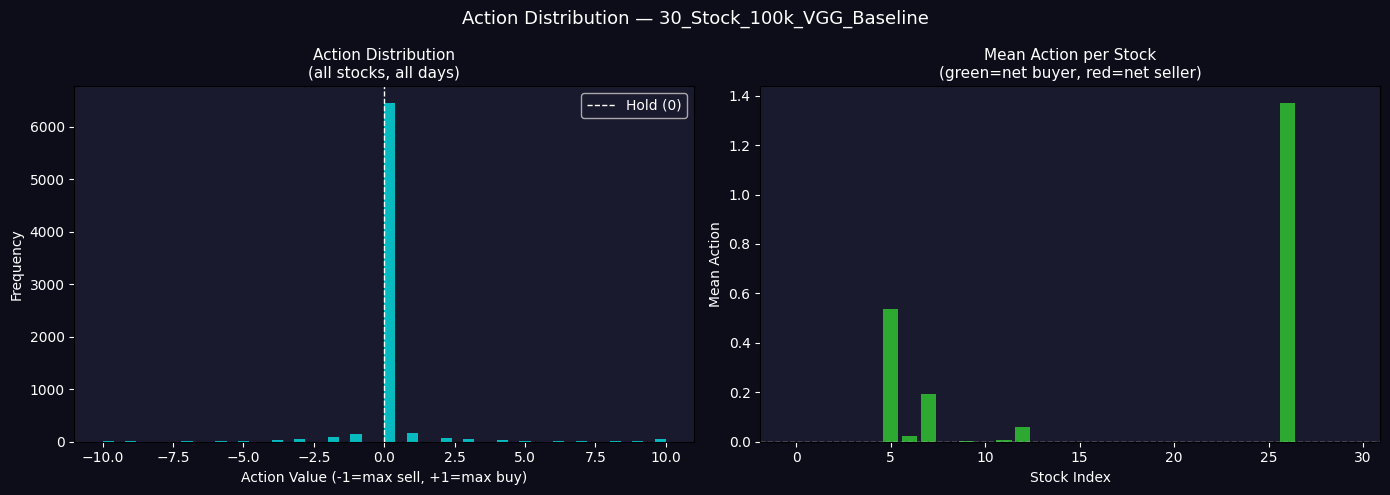

Look-ahead bias check skipped — no sentiment in this model
Buy-and-Hold: 30 stocks, $3,333 per stock

  BUY-AND-HOLD METRICS
  Total Return (%)               39.34
  Sharpe Ratio                   1.974
  Max Drawdown (%)              -10.82
  Win Rate (%)                   57.37
  Avg Daily Return (%)          0.1367
  Volatility (%)                 14.91
  Calmar Ratio                   3.636
  MARKET REGIME ANALYSIS

  H1 2024 — Bull Market (Jan-Jun):
  30_Stock_100k_VGG_Baseline                 Sharpe:  1.254  Return:   16.44%  MaxDD:  -15.36%  WinRate:  52.0%
  Buy-and-Hold                               Sharpe:  3.410  Return:   26.23%  MaxDD:   -5.79%  WinRate:  56.1%

  H2 2024 — Volatile (Jul-Dec):
  30_Stock_100k_VGG_Baseline                 Sharpe:  2.921  Return:   81.65%  MaxDD:  -19.86%  WinRate:  58.5%
  Buy-and-Hold                               Sharpe:  0.911  Return:    9.98%  MaxDD:  -10.82%  WinRate:  58.3%

  Full Period (Jan 2024 - Jan 2025):
  30_Stock_100k_VGG_Ba

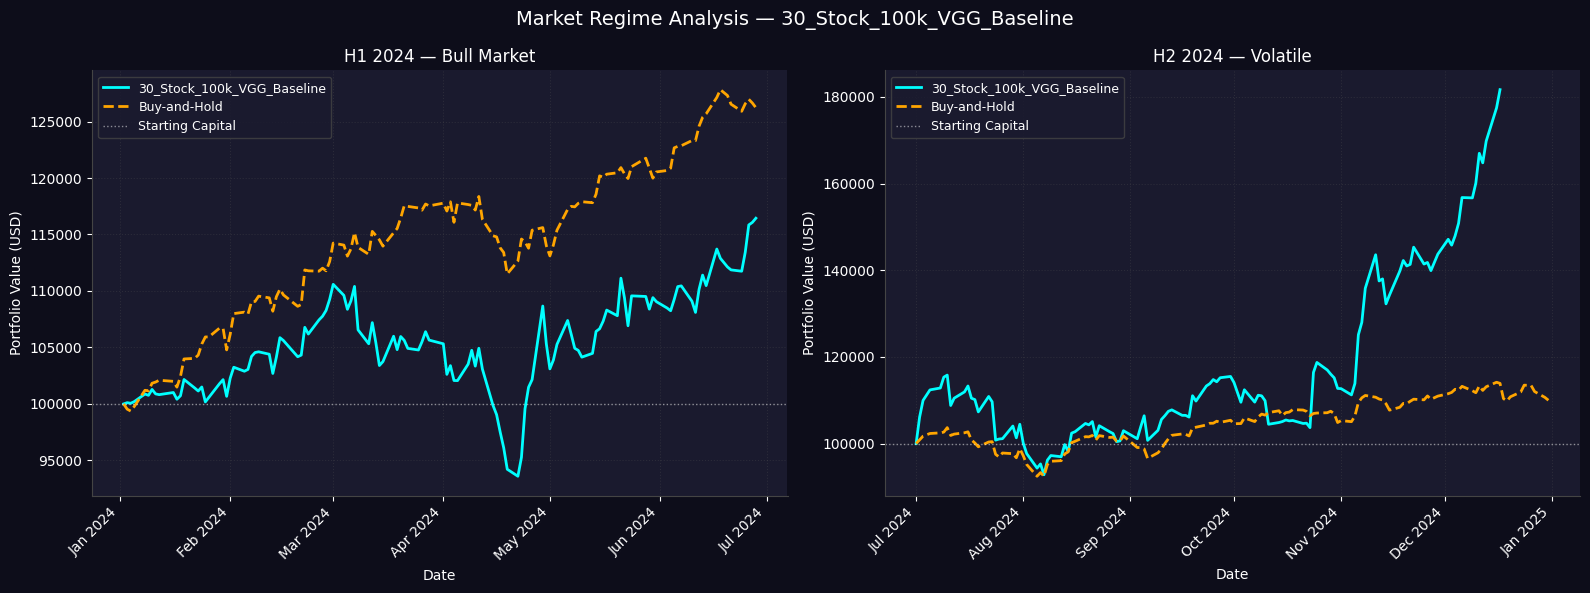

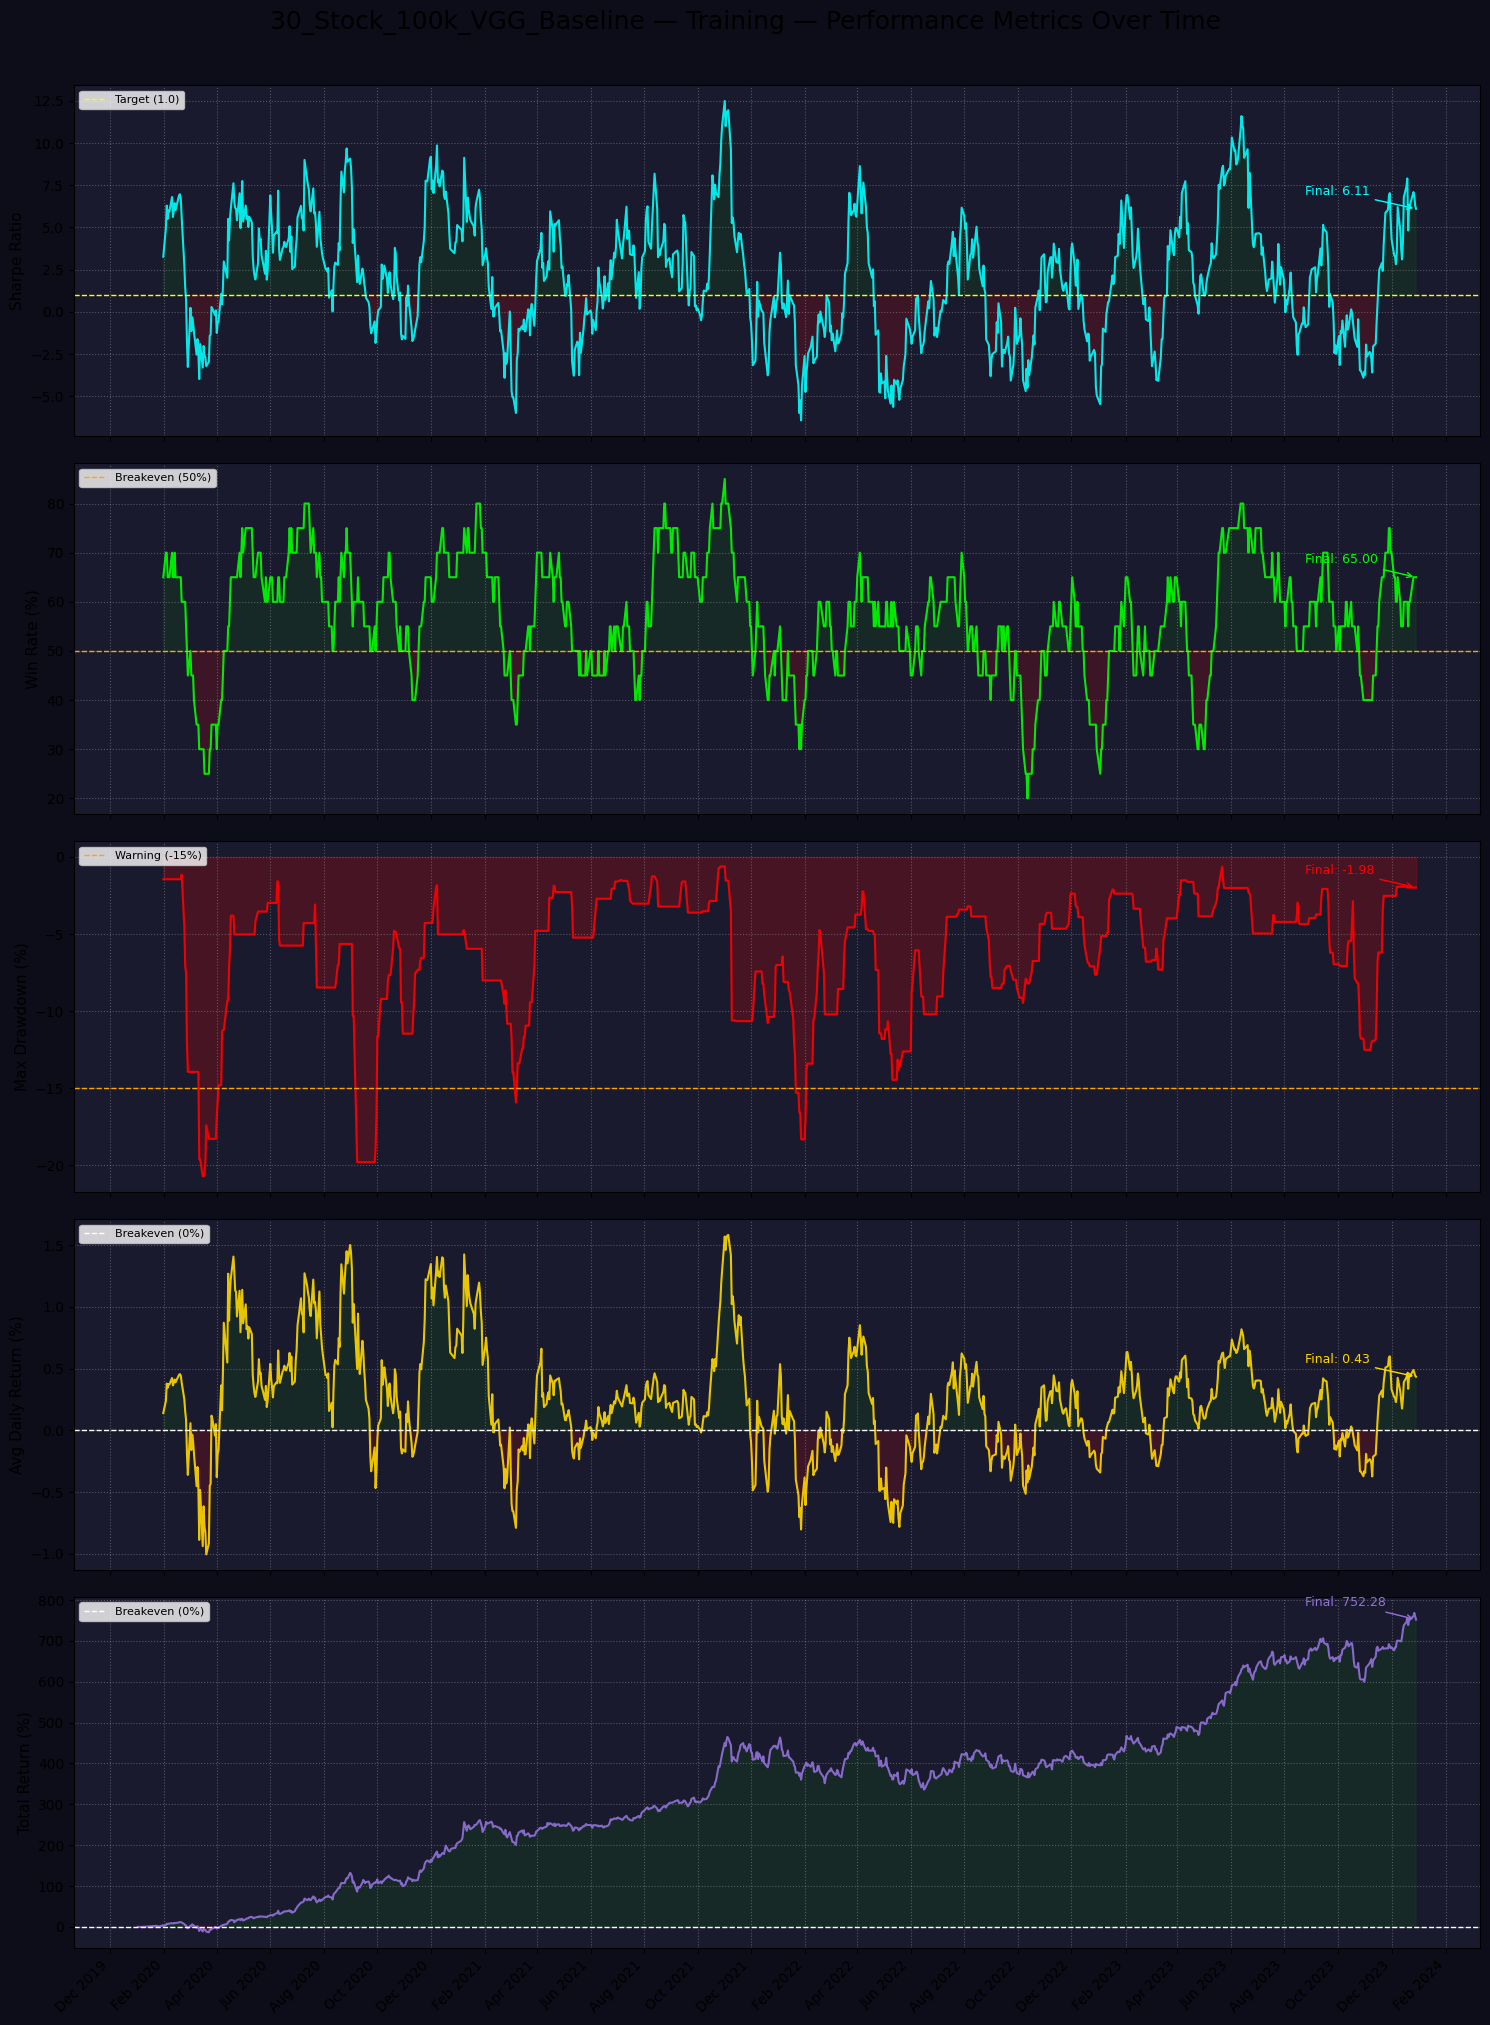


  30_STOCK_100K_VGG_BASELINE — TRAINING — FINAL METRIC VALUES
  Sharpe Ratio                   2.034  (avg)
  Win Rate (%)                  56.831  (avg)
  Max Drawdown (%)              -6.281  (avg)
  Avg Daily Return (%)           0.233  (avg)
  Total Return (%)             752.283  (final)


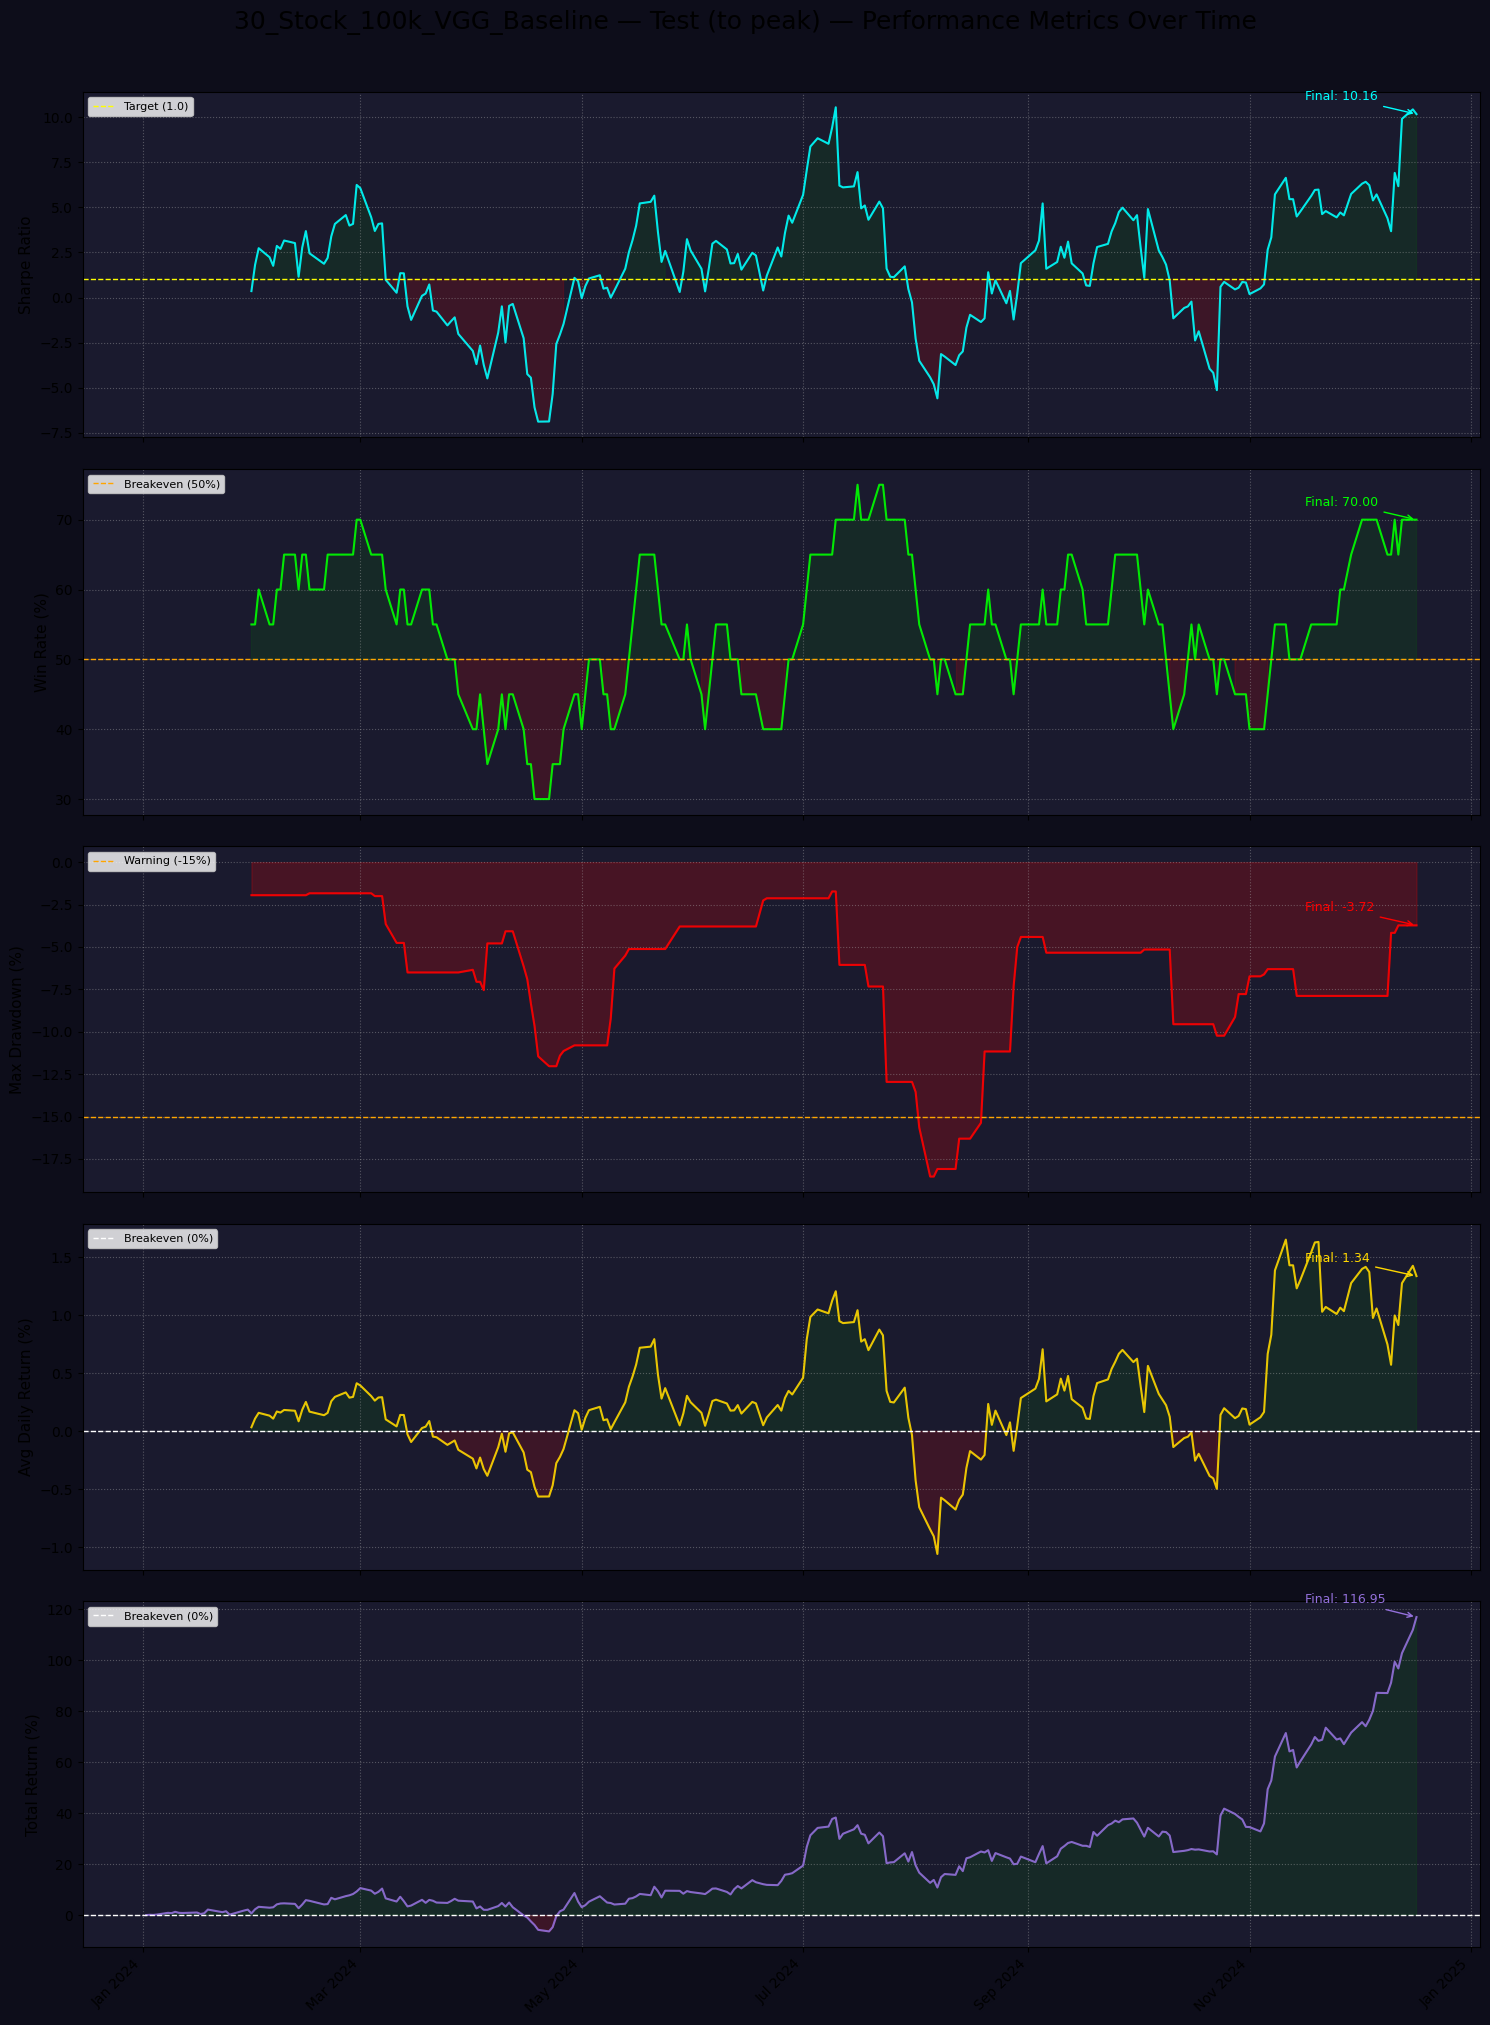


  30_STOCK_100K_VGG_BASELINE — TEST (TO PEAK) — FINAL METRIC VALUES
  Sharpe Ratio                   1.851  (avg)
  Win Rate (%)                  54.574  (avg)
  Max Drawdown (%)              -6.623  (avg)
  Avg Daily Return (%)           0.291  (avg)
  Total Return (%)             116.952  (final)

Pkl files saved: 6 files
Metrics summary: ./overlay_data/30_Stock_100k_VGG_Baseline_metrics_summary.txt

  EVALUATION COMPLETE — 30_Stock_100k_VGG_Baseline



In [6]:
# ── Baseline notebooks ────────────────────────────────────────
results = run_full_evaluation(
    trained_model   = trained_vgg,
    e_train_gym     = e_train_gym,
    e_test_gym      = e_test_gym,
    df_test         = df_test,
    model_name      = 'VGG_Baseline',   # change per notebook
    universe        = '30_Stock',        # change per notebook
    capital         = '100k',             # change per notebook
    initial_capital = 100_000,        # change per notebook
    has_sentiment   = False             # False for baseline only
)